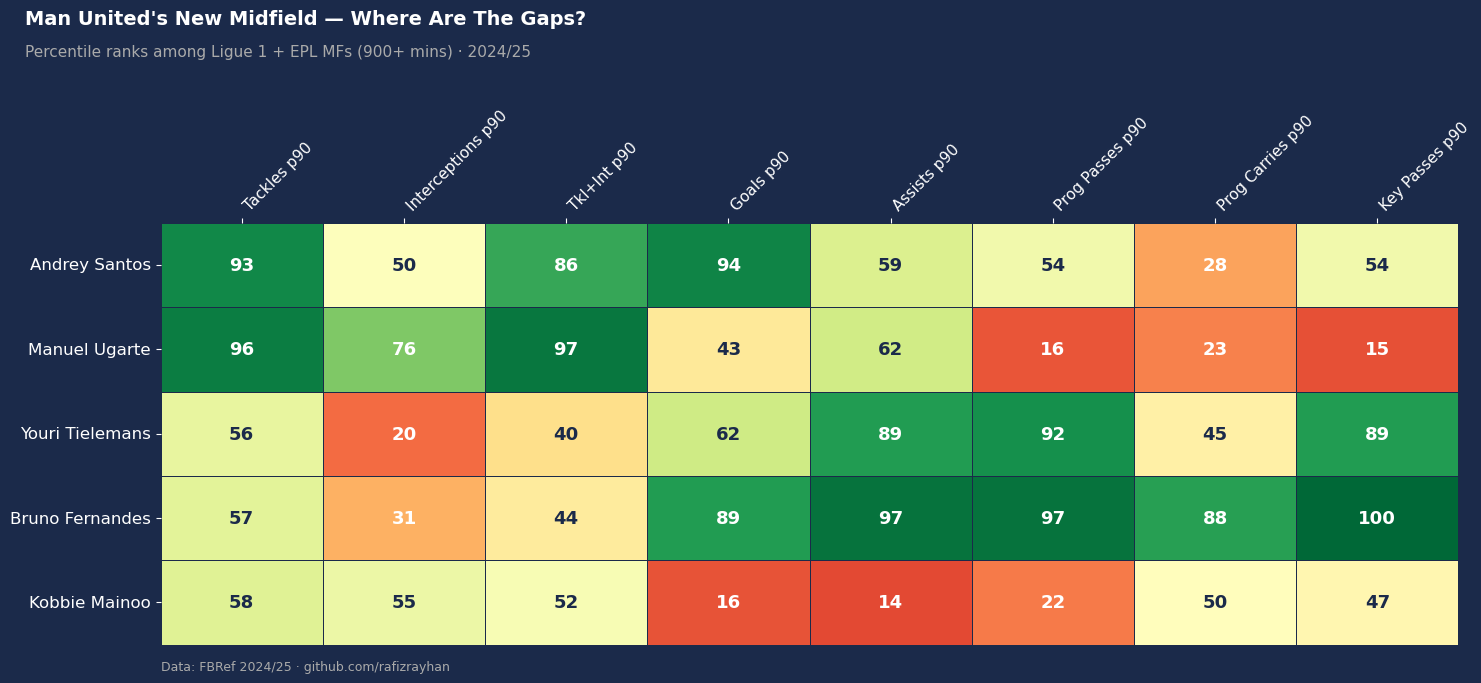

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── 1. Load and filter ───────────────────────────────────────────────
df = pd.read_csv('players_data-2024_2025.csv')

mf = df[
    (df['Pos'] == 'MF') &
    (df['Comp'].isin(['fr Ligue 1', 'eng Premier League'])) &
    (df['Min'] >= 900)
].copy().reset_index(drop=True)

# ── 2. Convert to numeric ────────────────────────────────────────────
cols = ['Tkl', 'Int', 'Tkl+Int', 'Gls', 'Ast', 'PrgP', 'PrgC', 'KP']
for col in cols:
    mf[col] = pd.to_numeric(mf[col], errors='coerce')

# ── 3. Calculate per-90 metrics ──────────────────────────────────────
mf['tkl_p90']     = mf['Tkl']     / mf['90s']
mf['int_p90']     = mf['Int']     / mf['90s']
mf['tkl_int_p90'] = mf['Tkl+Int'] / mf['90s']
mf['gls_p90']     = mf['Gls']     / mf['90s']
mf['ast_p90']     = mf['Ast']     / mf['90s']
mf['prgp_p90']    = mf['PrgP']    / mf['90s']
mf['prgc_p90']    = mf['PrgC']    / mf['90s']
mf['kp_p90']      = mf['KP']      / mf['90s']

metrics = ['tkl_p90', 'int_p90', 'tkl_int_p90', 'gls_p90',
           'ast_p90', 'prgp_p90', 'prgc_p90', 'kp_p90']

# ── 4. Calculate percentiles ─────────────────────────────────────────
united_players = {
    'Andrey Santos':   'Andrey Santos',
    'Manuel Ugarte':   'Ugarte',
    'Youri Tielemans': 'Youri Tielemans',
    'Bruno Fernandes': 'Bruno Fernandes',
    'Kobbie Mainoo':   'Kobbie Mainoo',
}

results = {}
for display_name, search_name in united_players.items():
    row = mf[mf['Player'].str.contains(search_name, na=False)]
    if len(row) == 0:
        print(f'{display_name}: NOT FOUND')
        continue
    row = row.iloc[0]
    pcts = []
    for metric in metrics:
        pct = stats.percentileofscore(mf[metric].dropna(), row[metric])
        pcts.append(round(pct, 1))
    results[display_name] = pcts

# ── 5. Build heatmap dataframe ───────────────────────────────────────
metric_labels = ['Tackles p90', 'Interceptions p90', 'Tkl+Int p90',
                 'Goals p90', 'Assists p90', 'Prog Passes p90',
                 'Prog Carries p90', 'Key Passes p90']

heatmap_df = pd.DataFrame(results, index=metric_labels).T

# ── 6. Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor('#1B2A4A')
ax.set_facecolor('#1B2A4A')

# Add title and subtitle using fig.suptitle and fig.text
fig.suptitle("Man United's New Midfield — Where Are The Gaps?",
             fontsize=14, fontweight='bold', color='white',
             x=0.02, y=0.98, ha='left', va='top')

fig.text(0.02, 0.93,
         'Percentile ranks among Ligue 1 + EPL MFs (900+ mins) · 2024/25',
         fontsize=11, color='#aaaaaa',
         ha='left', va='top', fontweight='normal')

sns.heatmap(
    heatmap_df,
    ax=ax,
    annot=False,
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor='#1B2A4A',
    cbar=False
)

# ── 7. Custom annotations with dynamic text colour ───────────────────
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        if 35 <= val <= 65:
            text_color = '#1B2A4A'
        else:
            text_color = 'white'
        ax.text(j + 0.5, i + 0.5, f'{int(round(val))}',
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                color=text_color)

# ── 8. Axis formatting ───────────────────────────────────────────────
ax.set_xlabel('', color='white')
ax.set_ylabel('', color='white')
ax.tick_params(colors='white', labelsize=12)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.xticks(rotation=45, ha='left', color='white', fontsize=11)
plt.yticks(rotation=0, color='white', fontsize=12)

ax.text(0.0, -0.06,
        'Data: FBRef 2024/25 · github.com/rafizrayhan',
        transform=ax.transAxes, fontsize=9, color='#aaaaaa', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig('united_midfield_heatmap.png', dpi=200,
            bbox_inches='tight', facecolor='#1B2A4A')
plt.show()

Lamine Camara: [np.float64(87.3), np.float64(83.6), np.float64(88.9), np.float64(57.7), np.float64(97.5), np.float64(80.6), np.float64(42.4), np.float64(90.4)]
Felix Nmecha: [np.float64(53.7), np.float64(85.2), np.float64(65.4), np.float64(89.8), np.float64(43.4), np.float64(63.0), np.float64(54.2), np.float64(47.2)]
Adam Wharton: [np.float64(67.9), np.float64(85.5), np.float64(77.8), np.float64(14.5), np.float64(75.3), np.float64(91.0), np.float64(33.0), np.float64(87.3)]
Carlos Baleba: [np.float64(78.7), np.float64(93.5), np.float64(88.3), np.float64(63.6), np.float64(28.4), np.float64(34.0), np.float64(64.5), np.float64(35.8)]
Manu Koné: [np.float64(17.6), np.float64(44.4), np.float64(23.5), np.float64(51.5), np.float64(29.6), np.float64(62.3), np.float64(91.0), np.float64(31.8)]

                Tackles p90  Interceptions p90  Tkl+Int p90  Goals p90  \
Lamine Camara         87.3               83.6         88.9       57.7   
Felix Nmecha          53.7               85.2         65.4

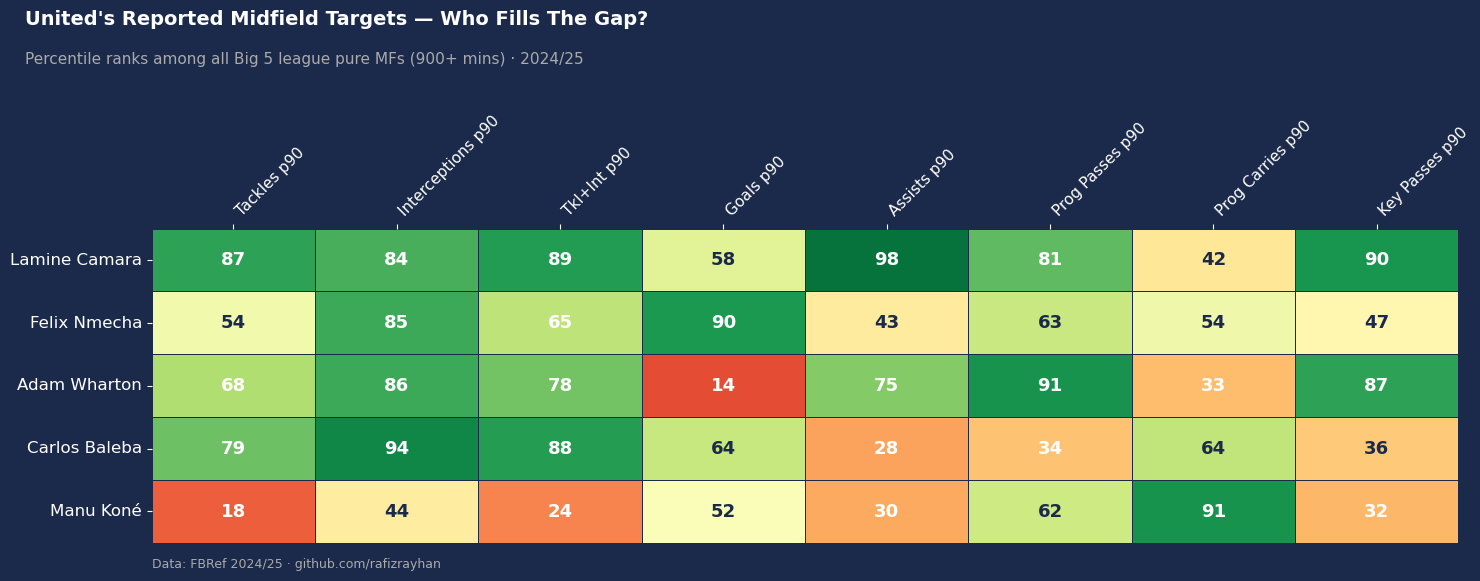

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── 1. Load and filter — ALL 5 leagues this time ─────────────────────
df = pd.read_csv('players_data-2024_2025.csv')

mf = df[
    (df['Pos'] == 'MF') &
    (df['Min'] >= 900)
].copy().reset_index(drop=True)

# ── 2. Convert to numeric ────────────────────────────────────────────
cols = ['Tkl', 'Int', 'Tkl+Int', 'Gls', 'Ast', 'PrgP', 'PrgC', 'KP']
for col in cols:
    mf[col] = pd.to_numeric(mf[col], errors='coerce')

# ── 3. Calculate per-90 metrics ──────────────────────────────────────
mf['tkl_p90']     = mf['Tkl']     / mf['90s']
mf['int_p90']     = mf['Int']     / mf['90s']
mf['tkl_int_p90'] = mf['Tkl+Int'] / mf['90s']
mf['gls_p90']     = mf['Gls']     / mf['90s']
mf['ast_p90']     = mf['Ast']     / mf['90s']
mf['prgp_p90']    = mf['PrgP']    / mf['90s']
mf['prgc_p90']    = mf['PrgC']    / mf['90s']
mf['kp_p90']      = mf['KP']      / mf['90s']

metrics = ['tkl_p90', 'int_p90', 'tkl_int_p90', 'gls_p90',
           'ast_p90', 'prgp_p90', 'prgc_p90', 'kp_p90']

# ── 4. Calculate percentiles ─────────────────────────────────────────
targets = {
    'Lamine Camara': 'Lamine Camara',
    'Felix Nmecha':  'Felix Nmecha',
    'Adam Wharton':  'Adam Wharton',
    'Carlos Baleba': 'Carlos Baleba',
    'Manu Koné':     'Manu Koné',
}

results = {}
for display_name, search_name in targets.items():
    row = mf[mf['Player'].str.contains(search_name.split()[0], na=False) &
             mf['Player'].str.contains(search_name.split()[-1], na=False)]
    if len(row) == 0:
        print(f'{display_name}: NOT FOUND')
        continue
    row = row.iloc[0]
    pcts = []
    for metric in metrics:
        pct = stats.percentileofscore(mf[metric].dropna(), row[metric])
        pcts.append(round(pct, 1))
    results[display_name] = pcts
    print(f'{display_name}: {pcts}')

# ── 5. Build heatmap dataframe ───────────────────────────────────────
metric_labels = ['Tackles p90', 'Interceptions p90', 'Tkl+Int p90',
                 'Goals p90', 'Assists p90', 'Prog Passes p90',
                 'Prog Carries p90', 'Key Passes p90']

heatmap_df = pd.DataFrame(results, index=metric_labels).T
print('\n', heatmap_df)

# ── 6. Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('#1B2A4A')
ax.set_facecolor('#1B2A4A')

# Title and subtitle
fig.suptitle("United's Reported Midfield Targets — Who Fills The Gap?",
             fontsize=14, fontweight='bold', color='white',
             x=0.02, y=0.98, ha='left', va='top')

fig.text(0.02, 0.91,
         'Percentile ranks among all Big 5 league pure MFs (900+ mins) · 2024/25',
         fontsize=11, color='#aaaaaa',
         ha='left', va='top', fontweight='normal')

sns.heatmap(
    heatmap_df,
    ax=ax,
    annot=False,
    cmap='RdYlGn',
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor='#1B2A4A',
    cbar=False
)

# ── 7. Custom annotations with dynamic text colour ───────────────────
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        if 35 <= val <= 65:
            text_color = '#1B2A4A'
        else:
            text_color = 'white'
        ax.text(j + 0.5, i + 0.5, f'{int(round(val))}',
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                color=text_color)

# ── 8. Axis formatting ───────────────────────────────────────────────
ax.set_xlabel('', color='white')
ax.set_ylabel('', color='white')
ax.tick_params(colors='white', labelsize=12)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.xticks(rotation=45, ha='left', color='white', fontsize=11)
plt.yticks(rotation=0, color='white', fontsize=12)

ax.text(0.0, -0.08,
        'Data: FBRef 2024/25 · github.com/rafizrayhan',
        transform=ax.transAxes, fontsize=9, color='#aaaaaa', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.89])
plt.savefig('united_transfer_targets_heatmap.png', dpi=200,
            bbox_inches='tight', facecolor='#1B2A4A')
plt.show()